In [1]:
import sys
# !{sys.executable} -m pip install xlrd

In [2]:
import pandas as pd
import os
import re

import arcpy
import pandas as pd
import geopandas as gpd

import json
# import asyncio
# import httpx


In [3]:
# name
project_name = 'korindo'

In [4]:
## arcgis project setup load
aprx = arcpy.mp.ArcGISProject('CURRENT')
print([m.name for m in aprx.listMaps()])

['gps', 'sra', 'korindo']


In [5]:
# setup map layer interaction arcpy
m = [m for m in aprx.listMaps() if m.name == project_name][0]

# check the list layers
print([l.name for l in m.listLayers()])

['LC_MoF_1990_2024_korindo_cleaned - deforestation_history', 'LC_MoF_1990_2024_korindo_cleaned - Zone', 'PL2024_AR_250K', 'LC_MoF_1990_2024_korindo_cleaned - LC 2024', 'LC_MoF_1990_2024_korindo_cleaned - LC 2015', 'LC_MoF_1990_2024_korindo_cleaned - LC 1990', 'LC_MoF_1990_2024_korindo_dissolved', 'LC_MoF_1990_2024_korindo', 'analysis_lulc', 'PL_1990_Clipped_korindo', 'PL_1990_Clipped_korindo_dis', 'PL_1996_Clipped_korindo', 'PL_1996_Clipped_korindo_dis', 'PL_2000_Clipped_korindo', 'PL_2000_Clipped_korindo_dis', 'PL_2003_Clipped_korindo', 'PL_2003_Clipped_korindo_dis', 'PL_2006_Clipped_korindo', 'PL_2006_Clipped_korindo_dis', 'PL_2009_Clipped_korindo', 'PL_2009_Clipped_korindo_dis', 'PL_2011_Clipped_korindo', 'PL_2011_Clipped_korindo_dis', 'PL_2012_Clipped_korindo', 'PL_2012_Clipped_korindo_dis', 'PL_2013_Clipped_korindo', 'PL_2013_Clipped_korindo_dis', 'PL_2014_Clipped_korindo', 'PL_2014_Clipped_korindo_dis', 'PL_2015_Clipped_korindo', 'PL_2015_Clipped_korindo_dis', 'PL_2016_Clipped_ko

In [12]:
# the original workspace location
scratch_local_folder = r'\\Mac\Home\Documents\ArcGIS\Projects\treeo_analysis\treeo_analysis.gdb'
# arcpy.env.workspace = scratch_local_folder # later do this again if needed to list the result

scratch_folder = "//Mac/Home/Documents/ArcGIS/Projects/treeo_analysis/"

#location of downloader webgis
workspace_downloader = r'C:\Users\q_bal\Documents\arcgis_restapi_notebooks\webgis_downloader'

In [13]:
dict_lc_fields = {
    'PL_1990': 'pl90_id',
    'PL_1996': 'pl96_id',
    'PL_2000': 'pl00_id',
    'PL_2003': 'pl03_id',
    'PL_2006': 'pl06_id',
    'PL_2009': 'pl09_id',
    'PL_2011': 'pl11_id',
    'PL_2012': 'pl12_id',
    'PL_2013': 'pl13_id',
    'PL_2014': 'pl14_id',
    'PL_2015': 'pl15_id',
    'PL_2016': 'pl16_id',
    'PL_2017': 'pl17_id',
    'PL_2018': 'PL_18_ID',
    'PL_2019': 'PL_19_R',
    'PL_2020': 'pl2020_id',
    'PL_2021': 'pl2021_id',
    'PL_2022': 'pl2022_id',
     'output_json_PL_2023_merge': 'PL2023_ID',
    'output_json_PL_2024_merge': 'PL2024_ID'
}

lc_fields = [fields for pl, fields in dict_lc_fields.items()]

desc_year ={
    'pl90_id':1990,
 'pl96_id':1996,
 'pl00_id':2000,
 'pl03_id':2003,
 'pl06_id':2006,
 'pl09_id':2009,
 'pl11_id':2011,
 'pl12_id':2012,
 'pl13_id':2013,
 'pl14_id':2014,
 'pl15_id':2015,
 'pl16_id':2016,
 'pl17_id':2017,
 'PL_18_ID':2018,
 'PL_19_R':2019,
 'pl2020_id':2020,
 'pl2021_id':2021,
 'pl2022_id':2022,
 'PL2023_ID':2023,
 'PL2024_ID':2024
} 

In [14]:
### analysis emission factor start from this cells forward
# acquire list of land use code reference
lc_code = r'C:\Users\q_bal\Documents\arcgis_restapi_notebooks\Landcover Code MoEF.csv'
lc_code_df = pd.read_csv(lc_code)
display(lc_code_df)

# pythonize object dict, list
lc_code_df_dict=lc_code_df['kode'].to_dict()
print(lc_code_df_dict)
lclist= []
for k in lc_code_df_dict.keys():
    temp = lc_code_df_dict[k]
    lclist.append(temp)
print(lclist)

,kode,keterangan,Description,Description2
0,2001,Hutan lahan kering primer,Primary Dryland Forest,Forested land
1,2002,Hutan lahan kering sekunder / bekas tebangan,Secondary Dryland Forest,Forested land
2,2005,Hutan rawa primer,Primary Swamp Forest,Forested land
3,20051,Hutan rawa sekunder / bekas tebangan,Secondary Swamp Forest,Forested land
4,2004,Hutan mangrove primer,Primary Mangrove Forest,Forested land
5,20041,Hutan mangrove sekunder / bekas tebangan,Secondary Mangrove Forest,Forested land
6,2006,Hutan tanaman,Plantation forest,NaN
7,2010,Perkebunan / Kebun,Estate crop,NaN
8,2007,Semak belukar,Dry shrub,Degraded land
9,20071,Semak belukar rawa,Wet shrub,Degraded land


{0: 2001, 1: 2002, 2: 2005, 3: 20051, 4: 2004, 5: 20041, 6: 2006, 7: 2010, 8: 2007, 9: 20071, 10: 3000, 11: 20091, 12: 20092, 13: 20093, 14: 20094, 15: 2012, 16: 20122, 17: 2014, 18: 20141, 19: 5001, 20: 50011, 21: 2500, 22: 20121}
[2001, 2002, 2005, 20051, 2004, 20041, 2006, 2010, 2007, 20071, 3000, 20091, 20092, 20093, 20094, 2012, 20122, 2014, 20141, 5001, 50011, 2500, 20121]


In [15]:
# function to convert feature class to df and later restructure to timeseries lulcc
def restructure_timeseries_lulcc(feature_class)  -> pd.DataFrame:

    # to pandas from feature class
    # feature_class = in_feature
    # feature_class = f'LC_MoF_1990_2024_{project_name}_cleaned' # hardcoded if you want to run directly  to this cell
    
    # Create a list to store the field names
    field_names = [field.name for field in arcpy.ListFields(feature_class)]
    
    # Use arcpy.da.SearchCursor to retrieve the data
    data = [row for row in arcpy.da.SearchCursor(feature_class, field_names)]
    
    # Convert the data to a Pandas DataFrame
    df = pd.DataFrame(data, columns=field_names)
     
    # df.columns
    
    # melt -> restructure data
    meltdf = pd.melt(df, id_vars=['area_ha'], value_vars=lc_fields )
    # meltdf

    Repiv = meltdf.pivot_table(values='area_ha',index=['value'],columns=['variable'],
                               aggfunc='sum', #margins=True
                              )
    # Repiv = Repiv.drop(columns="All")
    area_ha_lulcc = Repiv[lc_fields]
    # area_ha_lulcc

    lc_area_with_desc = pd.merge(area_ha_lulcc,lc_code_df[['kode','Description']], left_index=True, right_on='kode',
         how='left')
    lc_area_with_desc = lc_area_with_desc[['kode','Description'] + lc_fields]
    lc_area_with_desc.columns = ['code','description']+[year for code,year in desc_year.items()] 
    # lc_area_with_desc

    return lc_area_with_desc

In [16]:
## get the lulcc
layer_name = f'LC_MoF_1990_2024_{project_name}_cleaned'
lc_area_with_desc = restructure_timeseries_lulcc(layer_name)

In [33]:
display(lc_area_with_desc)

,code,description,1990,1996,2000,2003,2006,2009,2011,2012,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,2001,Primary Dryland Forest,620.673999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2002,Secondary Dryland Forest,1496.910548,1925.464227,1925.464227,1384.554681,1384.554681,1384.554681,1384.554681,1349.893288,...,1306.428829,1064.024557,1074.122657,1074.122657,1047.514595,2084.942960,2066.545318,2024.635173,2022.291623,2004.879555
8,2007,Dry shrub,8205.908472,NaN,NaN,540.909546,NaN,NaN,NaN,34.661393,...,67.746242,410.408243,410.408243,410.408243,410.408243,433.287167,402.936019,750.854687,751.822059,751.822059
7,2010,Estate crop,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,149.929593,240.509628,243.441295,550.065902,550.065902,550.065902
17,2014,Bare ground,3724.558863,11857.074990,11857.074990,11857.074990,9001.953482,8780.800157,8780.800157,8780.800157,...,8791.179767,8680.823938,688.293855,688.293855,1453.951721,1007.161585,525.376414,531.110455,532.486633,549.898702
19,5001,Open water,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.295416,0.295416,0.295416
3,20051,Secondary Swamp Forest,1678.510570,1678.510570,1678.510570,1678.510570,1678.510570,1678.510570,1678.510570,1678.510570,...,1678.510570,1514.220392,1678.510570,1678.510570,1605.118842,80.298705,81.415185,81.415185,81.415185,81.415185
11,20091,Pure dry agriculture,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,703.422976,703.422976,703.422976,703.422976
12,20092,Mixed dry agriculture,24277.919231,24543.431896,24543.431896,24543.431896,27939.462950,28160.616275,28160.616275,28160.616275,...,28160.616275,28335.004553,36153.146358,36153.146358,35212.763741,36033.486689,35859.096146,35240.433559,35224.246669,35224.246669
18,20141,Mining areas,17.429323,17.429323,17.429323,17.429323,17.429323,17.429323,17.429323,17.429323,...,17.429323,17.429323,17.429323,17.429323,142.224272,142.224272,139.677653,139.677653,155.864542,155.864542


In [34]:
lc_area_with_desc.description

0       Primary Dryland Forest 
1     Secondary Dryland Forest 
8                    Dry shrub 
7                  Estate crop 
17                 Bare ground 
19                  Open water 
3       Secondary Swamp Forest 
11        Pure dry agriculture 
12       Mixed dry agriculture 
18                Mining areas 
Name: description, dtype: object

In [35]:
## look at last 10 years
year_cols = [
    col for col in lc_area_with_desc.columns
    if str(col).isdigit() and int(col) >= 2014 # change into 2014
]

lc_10_years = lc_area_with_desc[['code','description']+year_cols]

In [36]:
def rgb_to_hex(rgb_color):
    """Converts an RGB list [R, G, B, Alpha] to a hex string '#RRGGBB'."""
    # The color values from ArcPy are 0-255.
    return '#{:02x}{:02x}{:02x}'.format(rgb_color[0], rgb_color[1], rgb_color[2])


# !!! CHANGE THIS to the name of your layer in the Contents pane !!!
layer_name = 'LC_MoF_1990_2024_korindo_cleaned - LC 1990'
lyr = m.listLayers(layer_name)[0]

color_map = {}

# Check if the layer has symbology and it's a unique value renderer
if lyr.isFeatureLayer and lyr.symbology:
    symbology = lyr.symbology
    if hasattr(symbology, 'renderer') and symbology.renderer.type == 'UniqueValueRenderer':
        
        print(f"Extracting colors from '{lyr.name}'...")
        
        # Loop through each symbol class (e.g., 'Hutan Primer', 'Semak/Belukar')
        for group in symbology.renderer.groups:
            for item in group.items:
                value = item.values[0][0]
                # print(item.values)
                # Get the color as an RGB list [R, G, B, A]
                rgb = item.symbol.color['RGB']
                # Convert to hex and add to our dictionary
                hex_code = rgb_to_hex(rgb)
                color_map[value] = hex_code

# Print the final dictionary, ready to be copied for Matplotlib
print("\n#--- Copy the dictionary below for your Matplotlib script ---#")
print(color_map)

# Example output might look like this:
# {'Hutan Lahan Kering Sekunder': '#60e663', 'Semak/Belukar': '#ebd0a7', ...}

Extracting colors from 'LC_MoF_1990_2024_korindo_cleaned - LC 1990'...

#--- Copy the dictionary below for your Matplotlib script ---#
{'2002': '#72ff00', '2007': '#ebc0a7', '2010': '#e5d298', '2014': '#d60073', '5001': '#d4fcf7', '20051': '#ffffff', '20091': '#f6fea7', '20092': '#edf500', '20141': '#a70400', '2001': '#65a843'}


In [37]:
color_map

{'2002': '#72ff00',
 '2007': '#ebc0a7',
 '2010': '#e5d298',
 '2014': '#d60073',
 '5001': '#d4fcf7',
 '20051': '#ffffff',
 '20091': '#f6fea7',
 '20092': '#edf500',
 '20141': '#a70400',
 '2001': '#65a843'}

In [38]:
df = lc_10_years
code_desc = dict(zip(df['code'], df['description']))
code_desc = {str(k):v for k,v in code_desc.items()}
code_desc

{'2001': 'Primary Dryland Forest ',
 '2002': 'Secondary Dryland Forest ',
 '2007': 'Dry shrub ',
 '2010': 'Estate crop ',
 '2014': 'Bare ground ',
 '5001': 'Open water ',
 '20051': 'Secondary Swamp Forest ',
 '20091': 'Pure dry agriculture ',
 '20092': 'Mixed dry agriculture ',
 '20141': 'Mining areas '}

In [39]:
sync_color_map = {v.rstrip():color_map[k] for k,v in code_desc.items()}
sync_color_map

{'Primary Dryland Forest': '#65a843',
 'Secondary Dryland Forest': '#72ff00',
 'Dry shrub': '#ebc0a7',
 'Estate crop': '#e5d298',
 'Bare ground': '#d60073',
 'Open water': '#d4fcf7',
 'Secondary Swamp Forest': '#ffffff',
 'Pure dry agriculture': '#f6fea7',
 'Mixed dry agriculture': '#edf500',
 'Mining areas': '#a70400'}

In [44]:
# df_transposed.to_csv(os.path.join(scratch_folder,'timeseries_lulc.csv'))

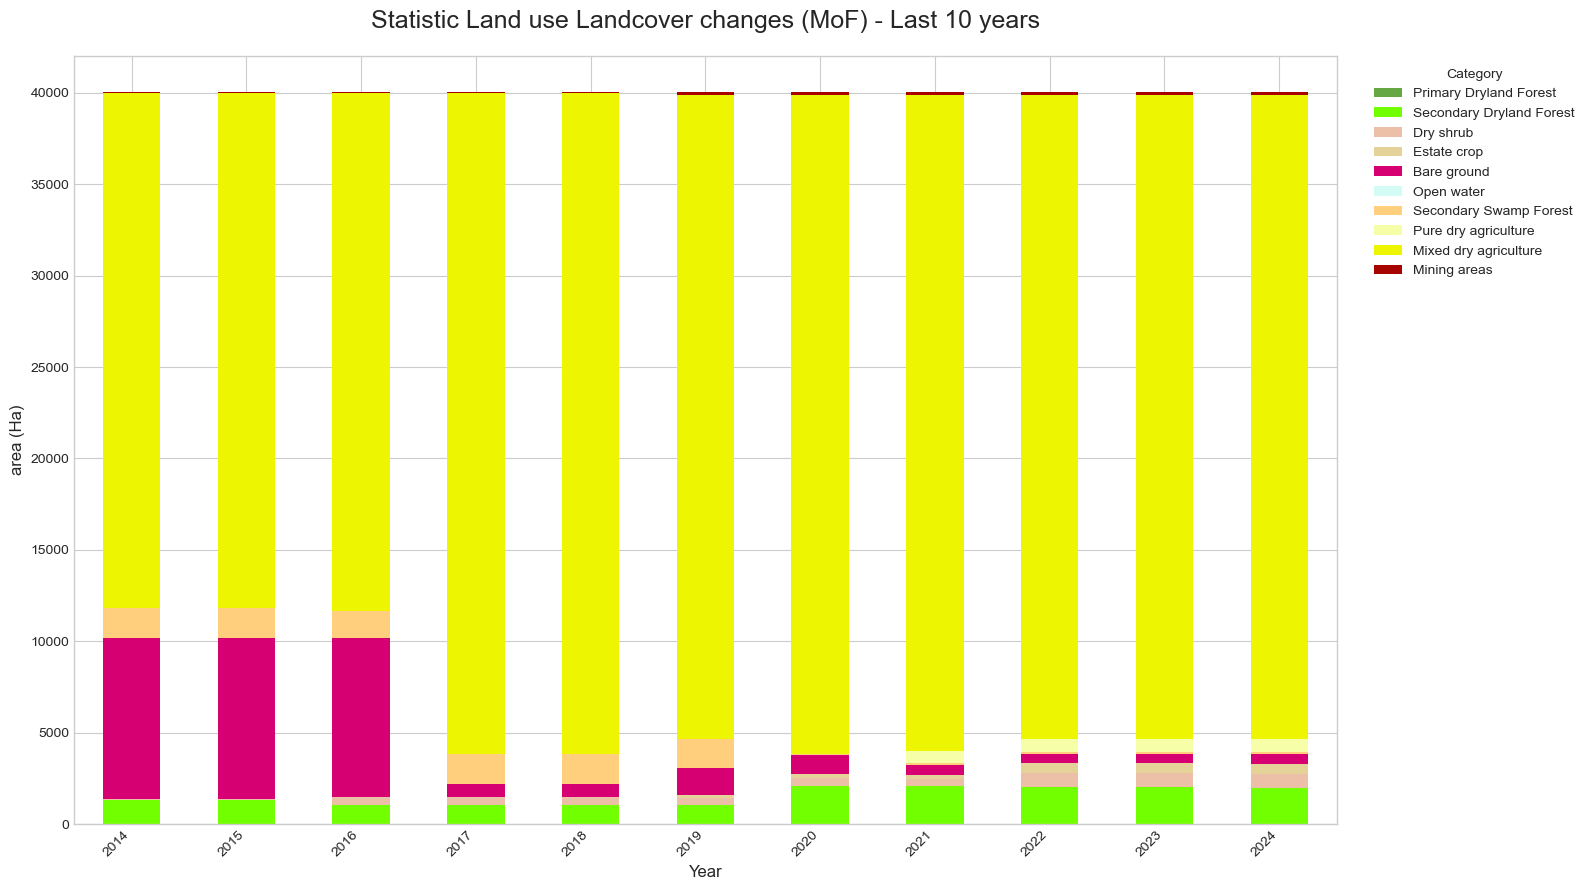

In [45]:
import matplotlib.pyplot as plt

#Transpose the DataFrame so that years become rows (for the x-axis)
# and categories become columns (for the stacks in each bar)
df = lc_10_years
df_transposed = df.T

column_name = [lc_class.rstrip() for lc_class in df_transposed.iloc[1].to_list()]
df_transposed.columns = column_name
df_transposed = df_transposed.iloc[2:]
df_transposed.index.name = "Year"

# Create and customize the plot
# Use a clean plot style
plt.style.use('seaborn-v0_8-whitegrid')

# 1. Define the new color map based on your description
# color_map = {
#     'Secondary Dryland Forest': '#006400',  # Dark Green
#     'Dry shrub': '#9ACD32',               # Green-Yellowish
#     'Settlement areas': '#FF69B4',         # Pink
#     'Bare ground': '#FF0000',             # Red
#     'Savanna and Grasses': '#90EE90',      # Light Green
#     'Pure dry agriculture': '#FFFF00',     # Yellow
#     'Mixed dry agriculture': '#FFA500'      # Orange
# }

# color_map_fix = sync_color_map
color_map_fix = {'Primary Dryland Forest': '#65a843',
 'Secondary Dryland Forest': '#72ff00',
 'Dry shrub': '#ebc0a7',
 'Estate crop': '#e5d298',
 'Bare ground': '#d60073',
 'Open water': '#d4fcf7',
 'Secondary Swamp Forest': '#ffcf7d',
 'Pure dry agriculture': '#f6fea7',
 'Mixed dry agriculture': '#edf500',
 'Mining areas': '#a70400'}

# Create the stacked bar chart from the transposed DataFrame
ax = df_transposed.plot(
    kind='bar',
    stacked=True,
    figsize=(16, 9), # Set the figure size for better readability
color=color_map_fix  # Apply the new custom colors
)

# Set titles and labels for clarity
ax.set_title('Statistic Land use Landcover changes (MoF) - Last 10 years', fontsize=18, pad=20)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('area (Ha)', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Adjust legend to be outside the plot area
ax.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')

# Ensure everything fits without overlapping
plt.tight_layout()

# 4. Show or save the plot
# To display the plot in a script or notebook:
plt.show()

In [46]:
# for i in df_transposed.columns:
#     print(i)

# refer to the FREL data:
frel_data = pd.read_csv(r'C:\Users\q_bal\Documents\arcgis_restapi_notebooks\FREL_DATA - combined_database_for_csv.csv')

print(frel_data['island_coverage'].unique())

# sulawesi for Muna --> forest, but indonesia for other land use
frel_kalimantan = frel_data[frel_data['island_coverage'].isin(['Kalimantan', 'Indonesia (Average)'])]

['Bali Nusa Tenggara \n ' 'Java ' 'Kalimantan' 'Maluku' 'Papua' 'Sulawesi'
 'Sumatra' 'Indonesia (Average)' 'Bali Nusa Tenggara' 'Java'
 'Bali Nusa Tenggara* \n' ' Java*\r\n' 'Maluku*' 'Sulawesi*'
 'Bali Nusa Tenggara* ' 'Bali Nusa Tenggara*\n' ' Java* \n' ' Kalimantan'
 'Sulawesi* ' 'Sumatra* ' 'Java*' 'Sumatra*']


In [47]:
frel_kalimantan

,land_cover_desc,land_cover_code,island_coverage,AGB_(Mg ha-1)_mean,AGB_(Mg ha-1)_SE,BGB_(Mg ha-1)_Mean,BGB_(Mg ha-1)_SE,Total_Ecosystem_(Mg ha-1)_Mean,Total_Ecosystem_(Mg ha-1)_SE,Uncertainty_percent
2,Primary \n Dryland \n Forest,2001,Kalimantan,325.90,10.05,94.51,2.89,420.41,10.45,4.90
7,Primary \n Dryland \n Forest,2001,Indonesia (Average),291.24,4.35,84.46,1.25,375.70,4.52,2.40
10,Secondary \n Dryland \n Forest,2002,Kalimantan,222.91,4.48,64.64,1.32,287.55,4.67,3.20
15,Secondary \n Dryland \n Forest,2002,Indonesia (Average),204.10,2.72,59.19,0.80,263.29,2.84,2.10
18,Primary \n Swamp \n Forest,2005,Kalimantan,285.09,24.16,62.72,7.10,347.81,25.18,14.20
23,Primary \n Swamp \n Forest,2005,Indonesia (Average),248.80,12.92,54.74,3.20,303.53,13.31,8.60
26,Secondary \n Swamp \n Forest,20051,Kalimantan,215.71,7.38,47.46,1.83,263.17,7.60,5.70
31,Secondary \n Swamp \n Forest,20051,Indonesia (Average),204.61,4.98,45.01,1.23,249.62,5.13,4.00
39,Primary \n Mangrove Forest,2004,Indonesia (Average),236.17,15.26,73.45,4.66,309.62,15.96,10.10
42,Secondary \n Mangrove \n Forest,20041,Kalimantan,155.74,19.21,17.91,2.32,173.66,19.35,21.80


In [48]:
list_df_frel = []
for code in frel_kalimantan.land_cover_code.unique():
    if len(frel_kalimantan[frel_kalimantan['land_cover_code']==code]['island_coverage'].unique()) > 1:
        filtered_df = frel_kalimantan[(frel_kalimantan['land_cover_code']==code) & (frel_kalimantan['island_coverage']=='Kalimantan')]
    else:
        filtered_df = frel_kalimantan[(frel_kalimantan['land_cover_code']==code)]

    list_df_frel.append(filtered_df)

unique_emission_factor = pd.concat(list_df_frel)

In [49]:
unique_emission_factor

,land_cover_desc,land_cover_code,island_coverage,AGB_(Mg ha-1)_mean,AGB_(Mg ha-1)_SE,BGB_(Mg ha-1)_Mean,BGB_(Mg ha-1)_SE,Total_Ecosystem_(Mg ha-1)_Mean,Total_Ecosystem_(Mg ha-1)_SE,Uncertainty_percent
2,Primary \n Dryland \n Forest,2001,Kalimantan,325.90,10.05,94.51,2.89,420.41,10.45,4.90
10,Secondary \n Dryland \n Forest,2002,Kalimantan,222.91,4.48,64.64,1.32,287.55,4.67,3.20
18,Primary \n Swamp \n Forest,2005,Kalimantan,285.09,24.16,62.72,7.10,347.81,25.18,14.20
26,Secondary \n Swamp \n Forest,20051,Kalimantan,215.71,7.38,47.46,1.83,263.17,7.60,5.70
39,Primary \n Mangrove Forest,2004,Indonesia (Average),236.17,15.26,73.45,4.66,309.62,15.96,10.10
42,Secondary \n Mangrove \n Forest,20041,Kalimantan,155.74,19.21,17.91,2.32,173.66,19.35,21.80
48,Plantation forest,2006,Indonesia (Average),75.78,7.52,24.63,2.44,100.40,7.91,15.44
49,Dry shrub,2007,Indonesia (Average),60.39,7.22,14.25,1.70,74.64,7.42,19.48
50,Estate crop,2010,Indonesia (Average),48.10,6.90,15.63,2.24,63.74,7.25,22.30
51,Settlement,2012,Indonesia (Average),2.17,1.17,0.63,0.34,2.80,1.21,85.18


In [50]:
df

,code,description,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,2001,Primary Dryland Forest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2002,Secondary Dryland Forest,1306.428829,1306.428829,1064.024557,1074.122657,1074.122657,1047.514595,2084.942960,2066.545318,2024.635173,2022.291623,2004.879555
8,2007,Dry shrub,67.746242,67.746242,410.408243,410.408243,410.408243,410.408243,433.287167,402.936019,750.854687,751.822059,751.822059
7,2010,Estate crop,NaN,NaN,NaN,NaN,NaN,149.929593,240.509628,243.441295,550.065902,550.065902,550.065902
17,2014,Bare ground,8791.179767,8791.179767,8680.823938,688.293855,688.293855,1453.951721,1007.161585,525.376414,531.110455,532.486633,549.898702
19,5001,Open water,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.295416,0.295416,0.295416
3,20051,Secondary Swamp Forest,1678.510570,1678.510570,1514.220392,1678.510570,1678.510570,1605.118842,80.298705,81.415185,81.415185,81.415185,81.415185
11,20091,Pure dry agriculture,NaN,NaN,NaN,NaN,NaN,NaN,NaN,703.422976,703.422976,703.422976,703.422976
12,20092,Mixed dry agriculture,28160.616275,28160.616275,28335.004553,36153.146358,36153.146358,35212.763741,36033.486689,35859.096146,35240.433559,35224.246669,35224.246669
18,20141,Mining areas,17.429323,17.429323,17.429323,17.429323,17.429323,142.224272,142.224272,139.677653,139.677653,155.864542,155.864542


In [51]:
merge_lulcc_ef = pd.merge(df, unique_emission_factor, left_on='code', right_on='land_cover_code',how='left')

In [52]:
col_time_series = [col for col in df.columns if isinstance(col, int)]

In [53]:
for col in col_time_series:
    merge_lulcc_ef[str(col)+'_stock_total_ecosystem'] = merge_lulcc_ef[col] * merge_lulcc_ef['Total_Ecosystem_(Mg ha-1)_Mean']
    merge_lulcc_ef[str(col)+'_tco2'] =  merge_lulcc_ef[str(col)+'_stock_total_ecosystem'] * (44/12) * 0.47

In [54]:
[col for col in merge_lulcc_ef.columns if not isinstance(col, int) and col.endswith('tco2')]

['2014_tco2',
 '2015_tco2',
 '2016_tco2',
 '2017_tco2',
 '2018_tco2',
 '2019_tco2',
 '2020_tco2',
 '2021_tco2',
 '2022_tco2',
 '2023_tco2',
 '2024_tco2']

In [55]:
# Calculate the sum and convert to a single-row DataFrame
total_df = pd.DataFrame(merge_lulcc_ef.sum(numeric_only=True)).T

# Set the index label for the new row to 'Total'
total_df.index = ['Total']
total_df.drop(columns='code')

,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,...,2020_stock_total_ecosystem,2020_tco2,2021_stock_total_ecosystem,2021_tco2,2022_stock_total_ecosystem,2022_tco2,2023_stock_total_ecosystem,2023_tco2,2024_stock_total_ecosystem,2024_tco2
Total,40021.911006,40021.911006,40021.911006,40021.911006,40021.911006,40021.911006,40021.911006,40021.911006,40021.911006,40021.911006,...,3.466077e+06,5.973206e+06,3.455926e+06,5.955712e+06,3.441421e+06,5.930716e+06,3.439568e+06,5.927522e+06,3.434613e+06,5.918983e+06


In [56]:
tco2_over_the_years = total_df[[col for col in merge_lulcc_ef.columns if not isinstance(col, int) and col.endswith('tco2')]]
tco2_over_the_years['average'] = tco2_over_the_years.mean(axis=1, numeric_only=True)
tco2_over_the_years # not emission, but this one is seq based on TDM in FREL

C:/Users/q_bal/AppData/Local/Temp/ArcGISProTemp388/xpython_388/4197116247.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tco2_over_the_years['average'] = tco2_over_the_years.mean(axis=1, numeric_only=True)


,2014_tco2,2015_tco2,2016_tco2,2017_tco2,2018_tco2,2019_tco2,2020_tco2,2021_tco2,2022_tco2,2023_tco2,2024_tco2,average
Total,5.226355e+06,5.226355e+06,5098542.868,6.182136e+06,6.182136e+06,6.030360e+06,5.973206e+06,5.955712e+06,5.930716e+06,5.927522e+06,5.918983e+06,5.786547e+06


In [57]:
tco2_over_the_years.to_csv(os.path.join(scratch_folder, 'over_years_tco2_total.csv'))

In [58]:
# df.columns

In [59]:
##################### now lets do the pivot, wall to wall 2015 vs 2024 dataset (LULCC)
### identifying emission from deforestation and forest degradation
layer_name = f'LC_MoF_1990_2024_{project_name}_cleaned'
# Create a list to store the field names
field_names = [field.name for field in arcpy.ListFields(layer_name)]

# Use arcpy.da.SearchCursor to retrieve the data
data = [row for row in arcpy.da.SearchCursor(layer_name, field_names)]

# Convert the data to a Pandas DataFrame
df = pd.DataFrame(data, columns=field_names)

# df

pivot_2015_2024 = pd.pivot_table(df, index='pl15_id', columns='PL2024_ID', values='area_ha', aggfunc='sum')

In [60]:
### exmple matrix mode two set of timeseries year
pivot_2015_2024

PL2024_ID,2002,2007,2010,2014,5001,20051,20091,20092,20141
pl15_id,,,,,,,,,
2002.0,1054.226449,229.240175,22.962204,NaN,NaN,NaN,NaN,NaN,NaN
2007.0,18.553787,49.192455,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014.0,NaN,147.644502,46.952021,136.215561,NaN,NaN,703.422976,7752.267630,4.677078
20051.0,929.509049,NaN,NaN,59.410069,NaN,80.298705,NaN,569.233931,40.058815
20092.0,2.590269,325.744927,480.151677,354.273072,0.295416,1.116480,NaN,26902.745108,93.699326
20141.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.429323


In [61]:
code_desc_int = {int(k):v for k,v in code_desc.items()}
pivot_2015_2024 = pivot_2015_2024.rename(columns=code_desc_int)
pivot_2015_2024 = pivot_2015_2024.rename(index=code_desc_int)

In [62]:
### If we want to look at the detail over the years
# clean up
df = pd.DataFrame(data, columns=field_names)
df.columns = [desc_year.get(col,col) for col in df.columns]
df.columns

non_year = [col for col in df.columns if isinstance(col, str)]
year = sorted([col for col in df.columns if isinstance(col, int) and col >= 2015]) # FILTER TO last 10 years!
# non_year
df = df[non_year + year]
df_2 = df.copy()

# assuming there is no peat land in the area, 
# (need to ensure though in reality, intersecting/ overlaying those data peatland and land cover)
# if peatland vs mineral (dry) land data is found, we should group class, which land cover is forest vs no forest

forested_land = [2001,2002,2004,2005,20041,20051] # 2006 (plantation forest, is categorized as non-forest (avoid) deforestation definition)
non_forested_land = [2006,2007,2010,2012,2014,2500,3000,5001,20071,20091,20092,20093,20094,20121,20122,20141,50011]

def deforested(df_input,x0,x1):
    df_input[str(x1)+f"_Deforested"] = (df_input[x0].isin(forested_land)) & (df_input[x1].isin(non_forested_land))

def check_last_lc(df, x0, x_def1):
    last_lc = 0
    if df[x_def1]:
        last_lc = df[x0]
    return last_lc

# we will focus on 2015 onward
X0 = [
    # 1990, 1996, 2000, 2006, 2009, 2011, 
      # 2012, 2013, 2014, 
      2015, 2016, 2017, 
      2018, 2019, 2020, 2021, 2022, 2023]
X1 =  [
      #1996, 2000, 2006, 2009, 2011, 
      #2012, 2013, 2014, 2015, 
      2016, 2017, 
      2018, 2019, 2020, 2021, 2022,2023,2024]

df_2['last_lc'] = 0  # Initialize the 'last_lc' column with zeros
df_2['year_deforested'] = 0 # initialize year_deforested
x_def1 = [str(i)+'_Deforested' for i in X1]
for i in range(len(X0)):
#    print(X1[i])
#    df_calc[X1[i]+"_Deforested"] = deforested(df_calc,X0[i],X1[i])
    deforested(df_2,X0[i],X1[i])
    df_2['last_lc'] = df_2.apply(lambda row: check_last_lc(row, X0[i], x_def1[i]) if row['last_lc'] == 0 else row['last_lc'], axis=1)
    df_2['year_deforested'] = df_2.apply(lambda x: X1[i] if x[x_def1[i]] == True else x['year_deforested'], axis =1)


In [63]:
df_2['type_land'] = 'dry_land' # need to adjust this by overlaying the area of peatland based on MoEF or Planology data

In [64]:
code_desc_int

{2001: 'Primary Dryland Forest ',
 2002: 'Secondary Dryland Forest ',
 2007: 'Dry shrub ',
 2010: 'Estate crop ',
 2014: 'Bare ground ',
 5001: 'Open water ',
 20051: 'Secondary Swamp Forest ',
 20091: 'Pure dry agriculture ',
 20092: 'Mixed dry agriculture ',
 20141: 'Mining areas '}

In [65]:
# current_recent years
current_year = 2024
ten_years_start = 2014
unplantable_lc = [20141, # mining areas
                 ]

# assign 10 years rule and label
df_2['10_years_rule'] = df_2.apply(lambda x: True if x['year_deforested'] >= ten_years_start else False, axis=1)
df_2['forest_high_baseline'] = df_2.apply(lambda x: True if x[current_year] in(forested_land) else False, axis=1)

df_2['unplantable_lc'] = df_2.apply(lambda x: True if x[current_year] in(unplantable_lc) else False, axis=1)

df_2['eligibility_arr'] = df_2.apply(lambda x: True if not(x['forest_high_baseline']) and not(x['10_years_rule']) and not(x['unplantable_lc']) else False, axis=1)
df_2['eligibility_avoidance'] = df_2.apply(lambda x: True if x['forest_high_baseline'] and not(x['10_years_rule']) else False, axis=1)
df_2['arr_zone'] = df_2.apply(
    lambda x: f'Go-zone_{code_desc_int.get(x[current_year], "").rstrip()}' if x['eligibility_arr'] == True
    else (f'NO-Go-zone_{code_desc_int.get(x[current_year], "").rstrip()}' if x['10_years_rule'] == False 
          else 'NO-Go-zone_10_years_rule'),
    axis=1
)
df_2

,OBJECTID,Shape,area_ha,Shape_Length,Shape_Area,area_ha_1,last_lc,year_deforested,type_land,forest_high_baseline,...,2017_Deforested,2018_Deforested,2019_Deforested,2020_Deforested,2021_Deforested,2022_Deforested,2023_Deforested,2024_Deforested,10_years_rule,unplantable_lc
0,1,"(111.82653564479554, -0.43765878534565045)",512.502336,0.134270,4.163733e-04,512.502336,0.0,0,dry_land,True,...,False,False,False,False,False,False,False,False,False,False
1,2,"(111.83968914492394, -0.442247139736328)",5.095048,0.010395,4.139383e-06,5.095048,2002.0,2021,dry_land,False,...,False,False,False,False,True,False,False,False,True,False
2,3,"(111.81086162965957, -0.43790355773761286)",59.612157,0.030438,4.843082e-05,59.612157,2002.0,2016,dry_land,False,...,False,False,False,False,False,False,False,False,True,False
3,4,"(111.825982178157, -0.4471479094366944)",33.084848,0.039833,2.687922e-05,33.084848,0.0,0,dry_land,False,...,False,False,False,False,False,False,False,False,False,False
4,5,"(111.81111837179165, -0.4332727350786073)",10.379610,0.016067,8.432723e-06,10.379610,0.0,0,dry_land,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,82,"(111.74066922204138, -0.1784235752157454)",0.295416,0.007250,2.399994e-07,0.295416,0.0,0,dry_land,False,...,False,False,False,False,False,False,False,False,False,False
82,83,"(111.8912696065776, -0.2686153984741285)",22492.649202,4.151734,1.827344e-02,22492.649202,0.0,0,dry_land,False,...,False,False,False,False,False,False,False,False,False,False
83,84,"(111.71164758399979, -0.19952916513382923)",11.222253,0.013223,9.117112e-06,11.222253,0.0,0,dry_land,False,...,False,False,False,False,False,False,False,False,False,True
84,85,"(111.71603473966192, -0.19867962628717808)",34.912622,0.046280,2.836349e-05,34.912622,0.0,0,dry_land,False,...,False,False,False,False,False,False,False,False,False,True


In [66]:
df_2.columns

Index([            'OBJECTID',                'Shape',              'area_ha',
               'Shape_Length',           'Shape_Area',            'area_ha_1',
                    'last_lc',      'year_deforested',            'type_land',
       'forest_high_baseline',
       ...
            '2017_Deforested',      '2018_Deforested',      '2019_Deforested',
            '2020_Deforested',      '2021_Deforested',      '2022_Deforested',
            '2023_Deforested',      '2024_Deforested',        '10_years_rule',
             'unplantable_lc'],
      dtype='object', length=116)

In [67]:
# numpy_array

In [68]:
# df_2.columns

In [69]:
import numpy as np

arcpy.env.workspace = scratch_local_folder
arcpy.env.overwriteOutput = True

# --- 1. Prepare your DataFrame ---
# Your code to create df_2 goes here...
# Example placeholder:
# df_2 = pd.DataFrame({'OBJECTID': [1,2], 'type_land': ['Forest', np.nan], 'area_ha': [10.5, 20.1]})

df_2.columns = df_2.columns.astype(str)
filtered_columns = [             'OBJECTID',               
                     'area_ha',         
                             '2015',
       '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024',               
                    'last_lc',
             'year_deforested',       '2016_Deforested',
             '2017_Deforested',       '2018_Deforested',
             '2019_Deforested',       '2020_Deforested',
             '2021_Deforested',       '2022_Deforested',
             '2023_Deforested',       '2024_Deforested',
                   'type_land',         '10_years_rule',
        'forest_high_baseline',       'eligibility_arr',
       'eligibility_avoidance', 'arr_zone']

df_2 = df_2.copy()
df_2 = df_2[filtered_columns]

# This cleaning step is still essential
df_2['type_land'] = df_2['type_land'].fillna('').astype(str)

# --- 2. THE FIX: Define an Explicit Schema (Blueprint) ---
print("Defining explicit data types for conversion...")

# Calculate the maximum string length needed for 'type_land'
max_len = df_2['type_land'].str.len().max()
# Use 'U' for Unicode string, followed by the max length. Add a buffer.
type_land_dtype = f'U{max_len + 5}' 

# Create a list of tuples that maps each column to a specific NumPy dtype
# Common mappings: int64 -> 'i8', float64 -> 'f8', object/string -> 'U<length>'
dtype_list = []
for col in df_2.columns:
    if col == 'type_land':
        dtype_list.append((col, type_land_dtype))
    elif df_2[col].dtype == 'int64' or df_2[col].dtype == 'int32':
        dtype_list.append((col, 'i8')) # 8-byte integer
    elif df_2[col].dtype == 'float64':
        dtype_list.append((col, 'f8')) # 8-byte float
    else:
        # Fallback for any other text-like columns
        # You can get more specific if you have other text columns
        temp_max_len = df_2[col].astype(str).str.len().max()
        dtype_list.append((col, f'U{temp_max_len + 5}'))

print(f"Generated NumPy dtypes: {dtype_list}")

# Convert the DataFrame to a list of tuples first
records = list(df_2.to_records(index=False))

# Now create the NumPy array using the records AND your explicit dtype blueprint
numpy_array = np.array(records, dtype=dtype_list)


# --- 3. Convert DataFrame to an ArcGIS Table ---
out_table_name = "df_table_converted"
table_path = os.path.join(scratch_local_folder, out_table_name)

try:
    # Force delete the previous version to prevent any schema conflicts
    if arcpy.Exists(table_path):
        arcpy.management.Delete(table_path)
        print(f"Deleted existing table: {table_path}")

    print("Converting DataFrame to ArcGIS table with explicit schema...")
    # This will now use your blueprint instead of guessing
    arcpy.da.NumPyArrayToTable(numpy_array, table_path)
    print("Conversion complete.")

    # --- 4. Proceed with your Join ---
    # (Your join code, uncommented)
    fc_path = "LC_MoF_1990_2024_korindo_cleaned - LC 2024"
    join_field_fc = "OBJECTID" 
    join_field_df = "OBJECTID_1" # it will automatically change the old objectid into objectid_1 in the new table 
    fields_to_join = [field.name for field in arcpy.ListFields(table_path) if field.name != join_field_df] # Join all other fields
    
    print(f"Joining fields to {fc_path}...")
    arcpy.management.JoinField(
        in_data=fc_path,
        in_field=join_field_fc,
        join_table=table_path,
        join_field=join_field_df,
        fields=fields_to_join
    )
    print("✅ Join completed successfully!")

except arcpy.ExecuteError:
    print(arcpy.GetMessages(2))
except Exception as e:
    print(f"An error occurred: {e}")

Defining explicit data types for conversion...
Generated NumPy dtypes: [('OBJECTID', 'i8'), ('area_ha', 'f8'), ('2015', 'f8'), ('2016', 'f8'), ('2017', 'i8'), ('2018', 'i8'), ('2019', 'i8'), ('2020', 'f8'), ('2021', 'f8'), ('2022', 'f8'), ('2023', 'i8'), ('2024', 'i8'), ('last_lc', 'f8'), ('year_deforested', 'i8'), ('2016_Deforested', 'U10'), ('2017_Deforested', 'U10'), ('2018_Deforested', 'U10'), ('2019_Deforested', 'U10'), ('2020_Deforested', 'U10'), ('2021_Deforested', 'U10'), ('2022_Deforested', 'U10'), ('2023_Deforested', 'U10'), ('2024_Deforested', 'U10'), ('type_land', 'U13'), ('10_years_rule', 'U10'), ('forest_high_baseline', 'U10'), ('eligibility_arr', 'U10'), ('eligibility_avoidance', 'U10'), ('arr_zone', 'U40')]
Deleted existing table: \\Mac\Home\Documents\ArcGIS\Projects\treeo_analysis\treeo_analysis.gdb\df_table_converted
Converting DataFrame to ArcGIS table with explicit schema...
Conversion complete.
Joining fields to LC_MoF_1990_2024_korindo_cleaned - LC 2024...
✅ Join 

In [70]:
df_2.to_csv(os.path.join(scratch_folder, 'zone_arr.csv'))

In [71]:
# restructure data to get the aggregation
melt_def = pd.melt(df_2, id_vars=['OBJECTID','last_lc','area_ha'], value_vars= [str(x)+"_Deforested" for x in X1])
melt_def.head()

,OBJECTID,last_lc,area_ha,variable,value
0,1,0.0,512.502336,2016_Deforested,False
1,2,2002.0,5.095048,2016_Deforested,False
2,3,2002.0,59.612157,2016_Deforested,True
3,4,0.0,33.084848,2016_Deforested,False
4,5,0.0,10.379610,2016_Deforested,False


In [72]:
melt_def

,OBJECTID,last_lc,area_ha,variable,value
0,1,0.0,512.502336,2016_Deforested,False
1,2,2002.0,5.095048,2016_Deforested,False
2,3,2002.0,59.612157,2016_Deforested,True
3,4,0.0,33.084848,2016_Deforested,False
4,5,0.0,10.379610,2016_Deforested,False
...,...,...,...,...,...
769,82,0.0,0.295416,2024_Deforested,False
770,83,0.0,22492.649202,2024_Deforested,False
771,84,0.0,11.222253,2024_Deforested,False
772,85,0.0,34.912622,2024_Deforested,False


In [73]:
Repiv_def_2 = melt_def.pivot_table(values='area_ha',index=['variable','last_lc'],columns=['value'],aggfunc='sum', margins=True)
Repiv_def_2 = Repiv_def_2.reset_index()

# indexing for sorting the variable name, deforestation from 1996 to 2022
indx = [str(x)+"_Deforested" for x in X1]# + ["All"]

# implementing the categorical, for sorting
Repiv_def_2['variable'] = pd.Categorical(Repiv_def_2['variable'],indx)
# apply the sorting based on categorical
Repiv_def_2 = Repiv_def_2.sort_values(['variable'],ascending=[True]).reset_index(drop=True)

#Repiv_def = Repiv_def.iloc[:,:-1]

# renaming additional areas to confirm the data, total areas (total aoi)
Repiv_def_2 = Repiv_def_2.rename(columns={"All":"Total Area"})

#Repiv_def.info()
#display(indx)
# NOTICE there is NAN in the data, that means, there is no change in the areas, 
# if we want to check remaining forest, refer to the Landcover data later,

Repiv_def_2 = Repiv_def_2[Repiv_def_2['variable'].notna()]

display(Repiv_def_2)

value,variable,last_lc,False,True,Total Area
0,2016_Deforested,0.0,39074.095633,NaN,39074.095633
1,2016_Deforested,2002.0,139.747982,242.404272,382.152254
2,2016_Deforested,20051.0,401.372941,164.290179,565.663119
3,2017_Deforested,0.0,39074.095633,NaN,39074.095633
4,2017_Deforested,2002.0,382.152254,NaN,382.152254
5,2017_Deforested,20051.0,565.663119,NaN,565.663119
6,2018_Deforested,0.0,39074.095633,NaN,39074.095633
7,2018_Deforested,2002.0,382.152254,NaN,382.152254
8,2018_Deforested,20051.0,565.663119,NaN,565.663119
9,2019_Deforested,0.0,39074.095633,NaN,39074.095633


In [74]:
def apply_year(df, column):
    x = int(column[:4])
    return x

Repiv_def_2['year'] = Repiv_def_2['variable'].apply(lambda x: apply_year(Repiv_def_2, x))
Repiv_def_2['area_deforested_ha'] = Repiv_def_2[True]

In [75]:
Repiv_def_2_fix = Repiv_def_2.copy()

Repiv_def_2_fix = Repiv_def_2[['variable','last_lc','area_deforested_ha']]

# temporary fix, re-occuring deforestation should treat differently
Repiv_def_2_fix = Repiv_def_2_fix[(Repiv_def_2_fix['last_lc']!=0) & (Repiv_def_2_fix['area_deforested_ha'].notna())]                     

In [76]:
code_desc_int

{2001: 'Primary Dryland Forest ',
 2002: 'Secondary Dryland Forest ',
 2007: 'Dry shrub ',
 2010: 'Estate crop ',
 2014: 'Bare ground ',
 5001: 'Open water ',
 20051: 'Secondary Swamp Forest ',
 20091: 'Pure dry agriculture ',
 20092: 'Mixed dry agriculture ',
 20141: 'Mining areas '}

In [77]:
Repiv_def_2_fix['last_lc_desc'] = Repiv_def_2_fix.apply(lambda x: code_desc_int.get(x['last_lc']) , axis=1)
Repiv_def_2_fix.to_csv(os.path.join(scratch_folder, 'deforestation_area.csv'))

In [78]:
# example cross-checking
pivot_2015_2016 = pd.pivot_table(df, index=2015, columns=2016, values='area_ha', aggfunc='sum')
pivot_2015_2016 = pivot_2015_2016.rename(columns=code_desc_int)
pivot_2015_2016 = pivot_2015_2016.rename(index=code_desc_int)
pivot_2015_2016.to_csv(os.path.join(scratch_folder,'data_matrix_lulcc_2015_2016.csv'))

In [79]:
# pivot_2015_2024 = pd.pivot_table(df, index=2015, columns=2024, values='area_ha', aggfunc='sum')
# pivot_2015_2024

In [80]:
unique_emission_factor['tCO2_per_ha'] = unique_emission_factor['Total_Ecosystem_(Mg ha-1)_Mean'] * 0.47 * (44/12)

In [81]:
reference_def_emission = pd.merge(Repiv_def_2_fix, unique_emission_factor, left_on='last_lc', right_on='land_cover_code', 
                                  how='left')

In [82]:
reference_def_emission_total = reference_def_emission.copy()

reference_def_emission_total = reference_def_emission_total[['variable','last_lc', 
                                                             'tCO2_per_ha', 'area_deforested_ha']]
reference_def_emission_total['total_tco2e_emission'] = reference_def_emission_total['tCO2_per_ha'] * reference_def_emission_total['area_deforested_ha']

display(reference_def_emission_total)

,variable,last_lc,tCO2_per_ha,area_deforested_ha,total_tco2e_emission
0,2016_Deforested,2002.0,495.544500,242.404272,120122.103776
1,2016_Deforested,20051.0,453.529633,164.290179,74510.464453
2,2019_Deforested,2002.0,495.544500,26.608062,13185.478752
3,2019_Deforested,20051.0,453.529633,73.391729,33285.323745
4,2020_Deforested,20051.0,453.529633,487.391771,221046.611398
5,2021_Deforested,2002.0,495.544500,51.348601,25445.516825
6,2022_Deforested,2002.0,495.544500,42.055145,20840.196019
7,2022_Deforested,20051.0,453.529633,1.363952,618.592829
8,2023_Deforested,2002.0,495.544500,2.343550,1161.333454
9,2024_Deforested,2002.0,495.544500,17.392624,8618.819040


In [83]:
reference_def_emission_total.to_csv(os.path.join(scratch_folder, 'emission_deforestation.csv'))

In [85]:
# emission per year
reference_def_emission_total.total_tco2e_emission.sum()/10

51884.32589312615